# RBF Manual
- Albeiro Armando Navarro Rojas
- Diego Andrés Castro Carvajal
- Isaac David Jácome García

IA, Grupo: 01

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carga y Preprocesamiento de Datos
Cargar el dataset desde el archivo JSON y extraer las entradas (X) y salidas deseadas (YD).

In [2]:
with open('../jsons/dataset_rbf_3.json', 'r') as f:
    data_dict = json.load(f)

print("=== CARGA DE DATASET ===")
print(f"Dataset: {data_dict['dataset']}")
print(f"Entradas: {data_dict['features']}")
print(f"Número de patrones: {len(data_dict['data'])}")

x = []
yd = []
for item in data_dict['data']:
    x.append(item['input'])
    yd.append(item['output'])

x = np.array(x)
yd = np.array(yd).reshape(-1, 1)

print(f"\nPrimeros 5 patrones:")
for i in range(min(5, len(x))):
    print(f"  Patrón {i+1}: x={x[i]}, yd={yd[i][0]}")

=== CARGA DE DATASET ===
Dataset: clasificacion_4_clases_grande
Entradas: ['x1', 'x2', 'x3', 'x4']
Número de patrones: 1200

Primeros 5 patrones:
  Patrón 1: x=[0.782 1.512 0.49  0.291], yd=0
  Patrón 2: x=[0.806 0.308 0.232 1.819], yd=0
  Patrón 3: x=[0.497 0.021 0.828 1.208], yd=0
  Patrón 4: x=[ 0.66  -0.     2.728  0.547], yd=0
  Patrón 5: x=[1.187 1.322 1.346 2.751], yd=0


## 2. Parámetros de entradas

In [3]:
print(f"\nDimensiones:")
print(f"  x (entradas): {x.shape}")
print(f"  yd (salidas deseadas): {yd.shape}")
print(f"\nNúmero de entradas: {x.shape[1]}")
print(f"Número de salidas: {yd.shape[1]}")
print(f"Número de patrones: {x.shape[0]}")


Dimensiones:
  x (entradas): (1200, 4)
  yd (salidas deseadas): (1200, 1)

Número de entradas: 4
Número de salidas: 1
Número de patrones: 1200


## 3. Estadística descriptiva

In [4]:
print(f"\nEstadísticas por característica:")
print(f"  {'Entradas':<10} {'Min':<12} {'Max':<12} {'Media':<12} {'Desv.Std':<12}")
print(f"  {'-'*58}")

features = data_dict['features']

for i, feature in enumerate(features):
    col = x[:, i]
    print(f"  {feature:<10} {np.min(col):<12.4f} {np.max(col):<12.4f} "
          f"{np.mean(col):<12.4f} {np.std(col):<12.4f}")


Estadísticas por característica:
  Entradas   Min          Max          Media        Desv.Std    
  ----------------------------------------------------------
  x1         -1.5260      15.0470      6.9805       4.5339      
  x2         -1.2920      15.1760      6.9989       4.5280      
  x3         -1.2510      15.6920      7.0309       4.5467      
  x4         -1.0290      15.3680      7.0177       4.5524      


## 4. Partición del Dataset
Separar el dataset en tres conjuntos: entrenamiento (70%), validación (15%) y prueba (15%).

In [5]:
n_total = len(x)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

np.random.seed(42)
indices   = np.random.permutation(n_total)
train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train+n_val]
test_idx  = indices[n_train+n_val:]

x_train  = x[train_idx];  yd_train = yd[train_idx]
x_val    = x[val_idx];    yd_val   = yd[val_idx]
x_test   = x[test_idx];   yd_test  = yd[test_idx]

print("=== SEPARACIÓN DEL DATASET ===")
print(f"Total de patrones:     {n_total}")
print(f"  Entrenamiento (70%): {n_train}")
print(f"  Evaluación (15%):    {n_val}")
print(f"  Prueba (15%):        {n_test}")

print("\nDimensiones:")
print(f"  x_train: {x_train.shape}, yd_train: {yd_train.shape}")
print(f"  x_val:   {x_val.shape},   yd_val:   {yd_val.shape}")
print(f"  x_test:  {x_test.shape},  yd_test:  {yd_test.shape}")

=== SEPARACIÓN DEL DATASET ===
Total de patrones:     1200
  Entrenamiento (70%): 840
  Evaluación (15%):    180
  Prueba (15%):        180

Dimensiones:
  x_train: (840, 4), yd_train: (840, 1)
  x_val:   (180, 4),   yd_val:   (180, 1)
  x_test:  (180, 4),  yd_test:  (180, 1)


## 5. Parámetros de entrenamiento
Configuración de la Red RBF

In [6]:
num_centros        = 25
error_optimo       = 0.06

print("=== CONFIGURACIÓN DE LA RED RBF ===")
print(f"Número inicial de centros:        {num_centros}")
print("Función de activación:            Thin Plate Spline (FA = Ω² * ln(Ω))")
print(f"Error de aproximación óptimo:     {error_optimo}")

=== CONFIGURACIÓN DE LA RED RBF ===
Número inicial de centros:        25
Función de activación:            Thin Plate Spline (FA = Ω² * ln(Ω))
Error de aproximación óptimo:     0.06


## Funciones Auxiliares

In [7]:
def inicializar_centros(x, num_centros):
    # Valor mínimo y máximo
    x_min = np.min(x, axis=0); x_max = np.max(x, axis=0)
    # Matríz de centros
    r = np.zeros((num_centros, x.shape[1]))
    # Llenar matríz de centros
    for i in range(num_centros):
        for j in range(x.shape[1]):
            r[i, j] = np.random.uniform(x_min[j], x_max[j])
    return r

def calcular_distancias(x, r):
    d = np.zeros((x.shape[0], r.shape[0]))
    for i in range(x.shape[0]):
        for j in range(r.shape[0]):
            d[i, j] = np.sqrt(np.sum((x[i] - r[j]) ** 2))
    # Distancias de cada patron con cada neurona
    return d

def thin_plate_spline(omega):
    if omega <= 0: return 0
    return (omega ** 2) * np.log(omega)

def calcular_matriz_interpolacion(d):
    n_patrones, num_centros = d.shape
    fa = np.zeros((n_patrones, num_centros))

    for i in range(n_patrones):
        for j in range(num_centros):
            fa[i, j] = thin_plate_spline(d[i, j])

    a = np.zeros((n_patrones, num_centros + 1))
    a[:, 0] = 1;  a[:, 1:] = fa
    return a

def resolver_pesos(a, yd):
    return np.dot(np.linalg.pinv(a), yd)

def simular_red(x, r, w):
    return np.dot(calcular_matriz_interpolacion(calcular_distancias(x, r)), w)

def calcular_errores(yd, yr):
    # Error lineal
    EL  = yd - yr
    # Error Global
    EG  = np.sum(np.abs(EL)) / len(yd)
    # Error cuadrático medio
    MSE = np.mean(EL ** 2)
    # Regresión de la media cuadrática
    MSR = np.sum((yr - np.mean(yr)) ** 2) / len(yr)
    return EL, EG, MSE, MSR

def calcular_matriz_confusion(YD, YR):
    YD_c = np.round(YD.flatten()).astype(int)
    YR_c = np.round(YR.flatten()).astype(int)
    n_clases = max(np.max(YD_c), np.max(YR_c)) + 1
    mat = np.zeros((n_clases, n_clases), dtype=int)

    for i in range(len(YD_c)):
        mat[YD_c[i], YR_c[i]] += 1

    accuracy = np.sum(np.diag(mat)) / np.sum(mat) if np.sum(mat) > 0 else 0
    precisions, recalls, specificities, f1s = [], [], [], []

    for c in range(n_clases):
        TP = mat[c, c]
        FP = np.sum(mat[:, c]) - TP
        FN = np.sum(mat[c, :]) - TP
        TN = np.sum(mat) - TP - FP - FN
        prec = TP / (TP + FP) if (TP + FP) > 0 else 0
        rec  = TP / (TP + FN) if (TP + FN) > 0 else 0
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        f1   = 2*(prec*rec)/(prec+rec) if (prec+rec) > 0 else 0
        precisions.append(prec); recalls.append(rec)
        specificities.append(spec); f1s.append(f1)

    return mat, accuracy, np.mean(precisions), np.mean(recalls), np.mean(specificities), np.mean(f1s)

def graficar_matriz_confusion(mat, class_names, title):
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicción'); plt.ylabel('Valor Real')
    plt.title(title); plt.tight_layout()

def imprimir_metricas_conjunto(nombre, n, acc, prec, rec, spec, f1, EG, MSE, MSR, mat):
    print(f"\n{nombre} ({n} patrones):")
    print(f"  Accuracy:    {acc:.4f}")
    print(f"  Precision:   {prec:.4f}")
    print(f"  Recall:      {rec:.4f}")
    print(f"  Specificity: {spec:.4f}")
    print(f"  F1-Score:    {f1:.4f}")
    print(f"  EG:          {EG:.6f}")
    print(f"  MSE:         {MSE:.6f}")
    print(f"  MSR:         {MSR:.6f}")
    print(f"  Matriz de Confusión:\n    {mat}")

def graficar_yd_yr(YD_set, YR_set, titulo):
    plt.figure(figsize=(10, 5))
    plt.plot(YD_set, label='Salida Deseada (YD)', marker='o', linestyle='None', alpha=0.6)
    plt.plot(YR_set, label='Salida Red (YR)',     marker='x', linestyle='None', alpha=0.6)
    plt.xlabel('Patrón'); plt.ylabel('Valor')
    plt.title(titulo); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

def graficar_todo(tag, YD_train, YR_train, YD_val, YR_val, YD_test, YR_test,
                  mat_val, acc_val, f1_val, mat_test, mat_train, acc_test, f1_test,
                  EG_obtenido, error_ref):
    """Genera todas las gráficas estándar para un entrenamiento (o reentrenamiento)."""

    # 1. EG vs Error Óptimo
    plt.figure(figsize=(8, 5))
    plt.bar(['EG Obtenido', 'Error Óptimo'], [EG_obtenido, error_ref],
            color=['steelblue', 'tomato'], alpha=0.8, edgecolor='black')
    plt.axhline(y=error_ref, color='red', linestyle='--', label=f'Error Óptimo ({error_ref})')
    plt.ylabel('Error')
    plt.title(f'[{tag}] EG Obtenido vs Error Óptimo')
    plt.legend(); plt.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate([EG_obtenido, error_ref]):
        plt.text(i, v + 0.001, f'{v:.6f}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout(); plt.show()

    # 2. YD vs YR para Train, Val, Test
    for YD_set, YR_set, nombre in [
        (YD_train, YR_train, 'Entrenamiento'),
        (YD_val,   YR_val,   'Validación'),
        (YD_test,  YR_test,  'Prueba')
    ]:
        graficar_yd_yr(YD_set, YR_set, f'[{tag}] Conjunto de {nombre}: YD vs YR')

    # 3. Matrices de confusión Train, Val y Test
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    plt.sca(axes[0])
    graficar_matriz_confusion(mat_train,  ['Clase 0','Clase 1'],
                              f'[{tag}] Train - Acc:{acc_val:.4f} F1:{f1_val:.4f}')
    plt.sca(axes[1])
    graficar_matriz_confusion(mat_val,  ['Clase 0','Clase 1'],
                              f'[{tag}] Validation - Acc:{acc_val:.4f} F1:{f1_val:.4f}')
    plt.sca(axes[2])
    graficar_matriz_confusion(mat_test, ['Clase 0','Clase 1'],
                              f'[{tag}] Test - Acc:{acc_test:.4f} F1:{f1_test:.4f}')
    plt.tight_layout(); plt.show()

print("=== FUNCIONES AUXILIARES DEFINIDAS ===")

=== FUNCIONES AUXILIARES DEFINIDAS ===


## 6. Entrenamiento de la Red RBF

In [8]:
print("=== INICIALIZACIÓN DE CENTROS RADIALES ===")
np.random.seed(42)
R = inicializar_centros(x_train, num_centros)

print(f"Centros iniciales ({num_centros} centros):")
for i in range(num_centros):
    print(f"  R{i+1} = {R[i]}")

print("\n=== ENTRENAMIENTO DE LA RED RBF ===")
D = calcular_distancias(x_train, R)
A = calcular_matriz_interpolacion(D)
W = resolver_pesos(A, yd_train)

# Devuelve salidas simuladas para el conjunto de entrenamiento
yr_train = simular_red(x_train, R, W)
EL_train, EG_train, MSE_train, MSR_train = calcular_errores(yd_train, yr_train)

converge = EG_train <= error_optimo

print("\nResultados del entrenamiento:")
print(f"  Error General (EG): {EG_train:.6f}")
print(f"  Error Óptimo:       {error_optimo}")
print(f"  MSE:                {MSE_train:.6f}")
print(f"  MSR:                {MSR_train:.6f}")
print(f"\n{'CONVERGIÓ' if converge else 'NO convergió'} con {num_centros} centros.")

=== INICIALIZACIÓN DE CENTROS RADIALES ===
Centros iniciales (25 centros):
  R1 = [ 4.68125339 14.3643632  10.70392506  8.78720317]
  R2 = [ 1.05969693  1.27691776 -0.30237845 13.17369026]
  R3 = [ 8.43627909 10.36853921 -0.91481404 14.87461185]
  R4 = [12.27007189  2.20480047  1.71856536  1.97828375]
  R5 = [3.51620669 7.34968892 5.80352604 3.74628421]
  R6 = [8.61423802 1.0051849  3.5203064  4.97823514]
  R7 = [ 6.03244785 11.63827773  2.01007221  7.40290209]
  R8 = [ 8.29208665 -0.5270546   8.67142252  1.76708406]
  R9 = [-0.44789995 14.33424703 14.51970236 12.22629132]
  R10 = [3.522364   0.31646437 9.92389379 6.18818044]
  R11 = [ 0.49653967  6.86257336 -0.68936667 13.88112663]
  R12 = [2.76276064 9.61841698 3.83986529 7.49855534]
  R13 = [ 7.53462946  1.75218317 14.58425614 11.6808529 ]
  R14 = [14.04431596 13.44401681  8.51390245 14.08697183]
  R15 = [-0.05941376  1.93544578 -0.51234792  4.30544143]
  R16 = [ 4.91554872  3.17657586 12.283941    4.8206843 ]
  R17 = [ 3.12992763  

## 7. Simular
Evaluación del Modelo en Train / Val / Test

In [9]:
print("=== EVALUACIÓN DEL MODELO EN TRAIN / VAL / TEST ===")

yr_val = simular_red(x_val, R, W)
EL_val, EG_val, MSE_val, MSR_val = calcular_errores(yd_val, yr_val)

yr_test = simular_red(x_test, R, W)
EL_test, EG_test, MSE_test, MSR_test = calcular_errores(yd_test, yr_test)

print(f"\n  {'Conjunto':<18} {'EG':<12} {'MSE':<12} {'MSR':<12}")
print(f"  {'-'*54}")
print(f"  {'Train (70%)':<18} {EG_train:<12.6f} {MSE_train:<12.6f} {MSR_train:<12.6f}")
print(f"  {'Validation (15%)':<18} {EG_val:<12.6f} {MSE_val:<12.6f} {MSR_val:<12.6f}")
print(f"  {'Test (15%)':<18} {EG_test:<12.6f} {MSE_test:<12.6f} {MSR_test:<12.6f}")

=== EVALUACIÓN DEL MODELO EN TRAIN / VAL / TEST ===

  Conjunto           EG           MSE          MSR         
  ------------------------------------------------------
  Train (70%)        0.059898     0.006259     1.212787    
  Validation (15%)   0.063232     0.007271     1.370347    
  Test (15%)         0.056430     0.005541     1.218705    


## 8. Matrices de Confusión y Métricas de Clasificación

In [10]:
print("=== MATRICES DE CONFUSIÓN Y 5 MÉTRICAS ===")

mat_train,  acc_train,  prec_train,  rec_train,  spec_train,  f1_train  = calcular_matriz_confusion(yd_train,  yr_train)
mat_val,  acc_val,  prec_val,  rec_val,  spec_val,  f1_val  = calcular_matriz_confusion(yd_val,  yr_val)
mat_test, acc_test, prec_test, rec_test, spec_test, f1_test = calcular_matriz_confusion(yd_test, yr_test)

imprimir_metricas_conjunto("TRAIN SET", len(x_train),
    acc_train,  prec_train,  rec_train,  spec_train,  f1_train,
    EG_train,  MSE_train,  MSR_train,  mat_train)

imprimir_metricas_conjunto("VALIDATION SET", len(x_val),
    acc_val,  prec_val,  rec_val,  spec_val,  f1_val,
    EG_val,  MSE_val,  MSR_val,  mat_val)

imprimir_metricas_conjunto("TEST SET", len(x_test),
    acc_test, prec_test, rec_test, spec_test, f1_test,
    EG_test, MSE_test, MSR_test, mat_test)

=== MATRICES DE CONFUSIÓN Y 5 MÉTRICAS ===

TRAIN SET (840 patrones):
  Accuracy:    1.0000
  Precision:   1.0000
  Recall:      1.0000
  Specificity: 1.0000
  F1-Score:    1.0000
  EG:          0.059898
  MSE:         0.006259
  MSR:         1.212787
  Matriz de Confusión:
    [[214   0   0   0]
 [  0 227   0   0]
 [  0   0 205   0]
 [  0   0   0 194]]

VALIDATION SET (180 patrones):
  Accuracy:    1.0000
  Precision:   1.0000
  Recall:      1.0000
  Specificity: 1.0000
  F1-Score:    1.0000
  EG:          0.063232
  MSE:         0.007271
  MSR:         1.370347
  Matriz de Confusión:
    [[45  0  0  0]
 [ 0 33  0  0]
 [ 0  0 43  0]
 [ 0  0  0 59]]

TEST SET (180 patrones):
  Accuracy:    1.0000
  Precision:   1.0000
  Recall:      1.0000
  Specificity: 1.0000
  F1-Score:    1.0000
  EG:          0.056430
  MSE:         0.005541
  MSR:         1.218705
  Matriz de Confusión:
    [[41  0  0  0]
 [ 0 40  0  0]
 [ 0  0 52  0]
 [ 0  0  0 47]]


## 9. Gráficas del Entrenamiento

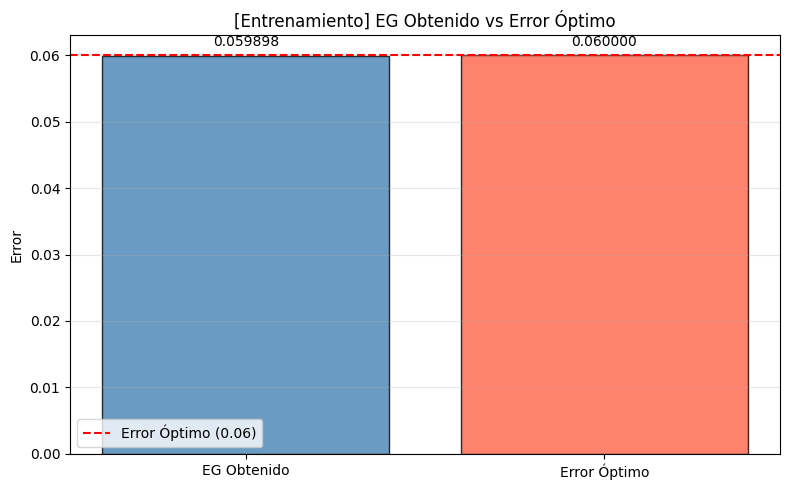

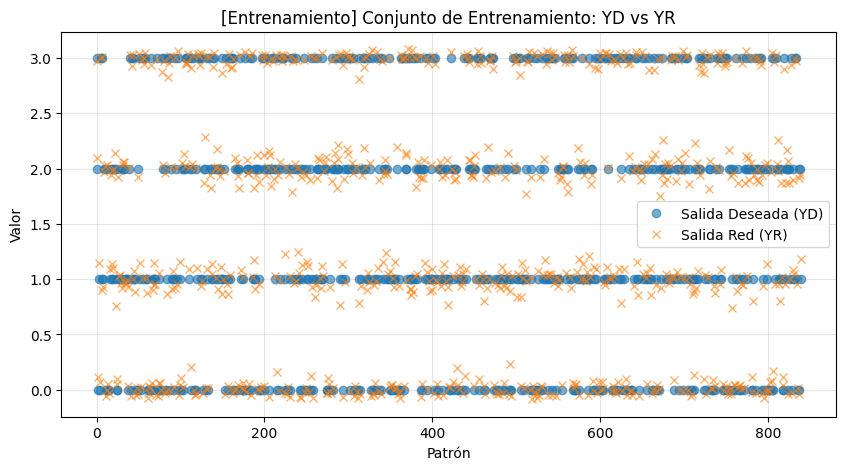

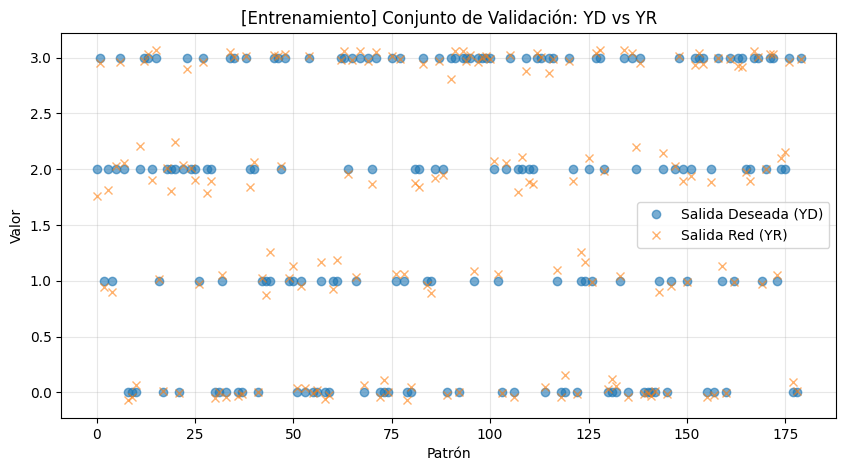

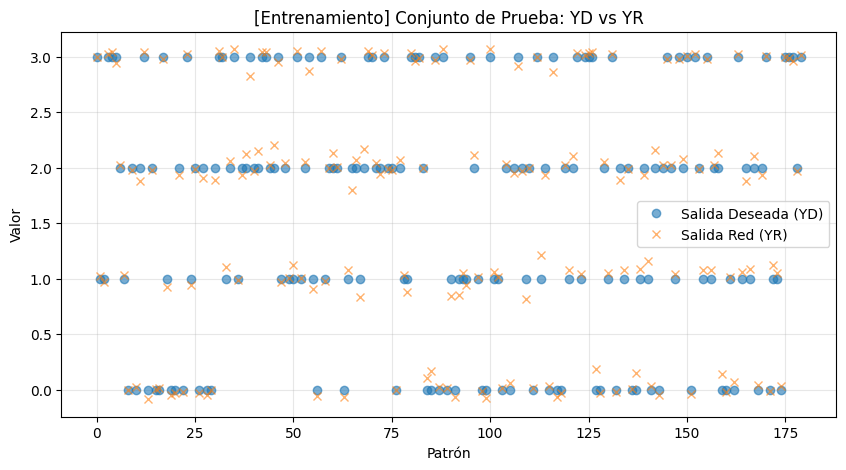

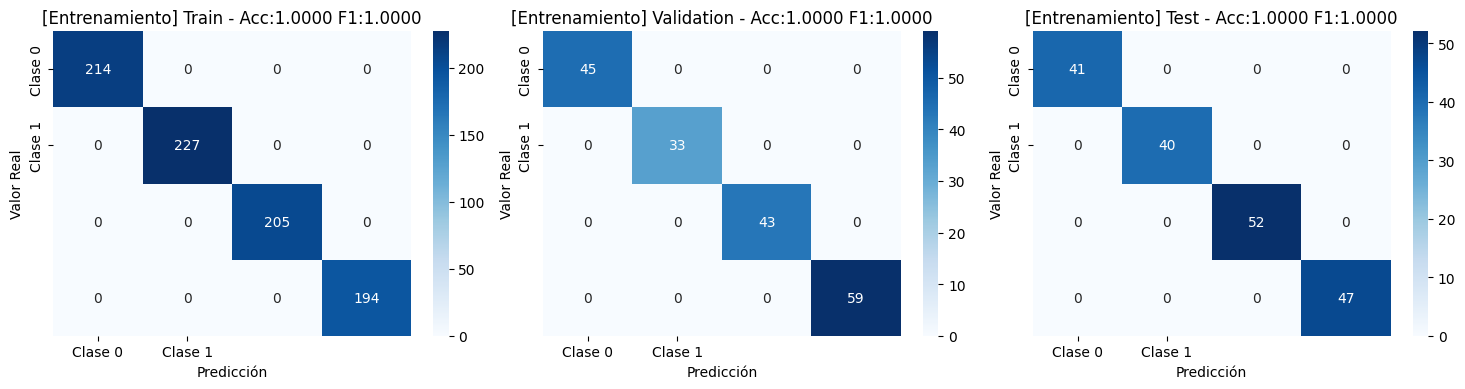

In [11]:
graficar_todo(
    tag='Entrenamiento',
    YD_train=yd_train, YR_train=yr_train,
    YD_val=yd_val,     YR_val=yr_val,
    YD_test=yd_test,   YR_test=yr_test,
    mat_val=mat_val,   acc_val=acc_val,   f1_val=f1_val,
    mat_test=mat_test, acc_test=acc_test, f1_test=f1_test,
    EG_obtenido=EG_train, error_ref=error_optimo, mat_train=mat_train
)